# NB-08 · Monte Carlo Multivariada — 10.000 Paths (Flagship)

**Análise Prescritiva — Camada Quantitativa · BYD Camaçari 2025–2027**

| Campo | Detalhe |
|---|---|
| **Notebook** | NB-08 · Monte Carlo Multivariada (S1×S2×S3×S4) |
| **Autor** | Matheus Mendes |
| **Data** | 27/julho/2026 |
| **Versão** | 1.0 |
| **Dependências** | numpy, scipy, plotly, matplotlib, pandas |

---

## Sumário

Notebook **flagship** da camada quantitativa: integra os quatro riscos modelados
isoladamente em NB-01…NB-04 num **único motor Monte Carlo multivariado** com
**4 choques simultâneos e correlacionados**, e destila o resultado em duas métricas
de risco de cauda — **VaR 95%** e **CVaR 95% (Expected Shortfall)** — mais um
**tornado de contribuição** e uma **matriz de decisão** acionável.

Os 4 choques (horizonte 6 meses, 126 dias úteis):

1. **PTAX / FX** — depreciação BRL/USD → encarece BOM importado (S1, NB-01)
2. **Lítio** — preço do carbonato de lítio → custo de células (S2, NB-02)
3. **Tarifa** — imposição de tarifa de importação (binária, S3/regulatório, NB-03)
4. **Demanda** — desvio de crescimento do mercado EV (S4, NB-04)

Os choques contínuos (FX, Lítio, Demanda) são gerados **correlacionados** via
**decomposição de Cholesky**; a Tarifa é um evento **Bernoulli** independente.

---

## Resultados-chave (CLIFF NOTES)

| Métrica | Valor | Interpretação |
|---|---|---|
| **VaR 95%** | **R$ 8,21 bi** | Perda no 5º percentil (pior 5% dos cenários 6m) |
| **CVaR 95%** | **R$ 10,14 bi** | Perda média DENTRO da cauda 5% (Expected Shortfall) |
| VaR 99% | R$ 11,40 bi | Cauda extrema (pior 1%) |
| VaR 90% | R$ 6,51 bi | Cauda moderada (pior 10%) |
| **Contribuinte #1** | **Tarifa — 29%** | Maior risco individual, **NÃO** o câmbio |
| Contribuinte #2 | Lítio — 25% | Preço do carbonato de lítio |
| Contribuinte #3 | PTAX/FX — 20% | Câmbio, apenas o 3º maior |
| Contribuinte #4 | Demanda — 15% | Incerteza de crescimento EV |
| Amplificação por correlação | +11% | Co-movimento eleva o VaR conjunto acima da soma |

> **Insight central:** a **Tarifa de importação é o maior risco individual (29%)**,
> não o câmbio (20%). A combinação dos 4 riscos correlacionados eleva o VaR 95%
> para **R$ 8,21 bi — ~3,5× o maior choque individual** (R$ 2,37 bi).

---

## Estrutura do Notebook

1. Setup & imports
2. Carregar parâmetros de NB-01…NB-07 (`outputs/nb0*_results.json`)
3. Especificar os 4 choques + matriz de correlação (Cholesky)
4. Rodar Monte Carlo — 10.000 paths × 6 meses
5. VaR 95% / 99% / 90% + CVaR 95% (Expected Shortfall)
6. Tornado chart — contribuição por choque
7. Matriz de decisão — triggers acionáveis
8. Convergência Monte Carlo (estabilidade do VaR)
9. Export → `outputs/nb08mc_results.json`

---

In [1]:
import json, warnings, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

warnings.filterwarnings('ignore')

# Paths
NOTEBOOK_ROOT = Path(r'C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva')
OUTPUT_DIR = NOTEBOOK_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
PREFIX = 'nb08mc'  # distinct from existing backtesting nb08_* artefacts

# Style: dark terminal (match pitch deck / NB-01)
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#2a3a50', 'axes.labelcolor': '#9baabb',
    'text.color': '#e8edf5', 'xtick.color': '#9baabb', 'ytick.color': '#9baabb',
    'grid.color': '#1e2a3a', 'grid.linewidth': 0.8,
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#2a3a50',
    'font.family': 'DejaVu Sans', 'font.size': 11,
})
try:
    import seaborn as sns
    sns.set_style('darkgrid')
except Exception:
    plt.style.use('dark_background')

# Palette (Atlas brand tokens)
C_BLUE, C_AMBER, C_GREEN, C_RED = '#4f8ef7', '#e8a23c', '#34d399', '#f87171'
C_RED2 = '#ff4d6d'

print('Python', sys.version.split()[0])
import importlib.metadata as _md
print('NumPy', np.__version__, '| Pandas', pd.__version__, '| plotly', _md.version('plotly'))
print('Output prefix:', PREFIX)

Python 3.14.6
NumPy 2.5.1 | Pandas 2.3.3 | plotly 6.8.0
Output prefix: nb08mc


---
## 2. Carregar parâmetros de NB-01…NB-07

O motor multivariado **não recalibra do zero**: ele consome os parâmetros já
estimados nos notebooks anteriores (`outputs/nb0*_results.json`). Cada choque
herda a volatilidade / probabilidade / impacto da sua camada de origem.

In [2]:
def load_json(name, default=None):
    p = OUTPUT_DIR / name
    if p.exists():
        with open(p, encoding='utf-8') as f:
            print(f'  [OK] {name}')
            return json.load(f)
    print(f'  [!] {name} ausente -- usando fallback')
    return default or {}

print('Carregando parametros:')
nb01 = load_json('nb01_results.json')
nb02 = load_json('nb02_results.json')
nb03 = load_json('nb03_results.json')
nb04 = load_json('nb04_results.json')
nb06 = load_json('nb06_results.json')
nb07 = load_json('nb07_results.json')

# Volatilidades anualizadas (herdadas)
FX_STD_ANN = nb01.get('ptax', {}).get('hist_vol_ann', 14.173) / 100.0
LITHIUM_STD_ANN = nb02.get('lithium', {}).get('vol_ann', 0.8311)
DEMAND_STD_ANN = nb06.get('shock_params', {}).get('demand_std_ann', 0.05)

# Tarifa (S3 regulatorio)
TARIFF_PROB = nb06.get('shock_params', {}).get('tariff_prob', 0.35)
TARIFF_IMPACT = abs(nb06.get('shock_params', {}).get('tariff_impact_B', 2.37))

# Exposicoes economicas headline (R$ bi) do framework D2/D3
HEADLINE_EXPO = {'Tarifa': TARIFF_IMPACT, 'Litio': 2.05, 'PTAX/FX': 1.64, 'Demanda': 1.23}

print()
print(f'  FX   sigma anual (NB-01): {FX_STD_ANN:.4f} ({FX_STD_ANN*100:.2f}%)')
print(f'  Li   sigma anual (NB-02): {LITHIUM_STD_ANN:.4f} ({LITHIUM_STD_ANN*100:.2f}%)')
print(f'  Dem  sigma anual (NB-06): {DEMAND_STD_ANN:.4f} ({DEMAND_STD_ANN*100:.2f}%)')
print(f'  Tarifa: prob={TARIFF_PROB:.0%}, impacto=R$ {TARIFF_IMPACT:.2f} bi (NB-06)')
print(f'  Exposicoes headline (R$ bi): {HEADLINE_EXPO}')

Carregando parametros:
  [OK] nb01_results.json
  [OK] nb02_results.json
  [OK] nb03_results.json
  [OK] nb04_results.json
  [OK] nb06_results.json
  [OK] nb07_results.json

  FX   sigma anual (NB-01): 0.1417 (14.17%)
  Li   sigma anual (NB-02): 0.8311 (83.11%)
  Dem  sigma anual (NB-06): 0.0500 (5.00%)
  Tarifa: prob=35%, impacto=R$ 2.37 bi (NB-06)
  Exposicoes headline (R$ bi): {'Tarifa': 2.37, 'Litio': 2.05, 'PTAX/FX': 1.64, 'Demanda': 1.23}


---
## 3. Especificacao dos 4 choques + matriz de correlacao

**Horizonte:** 6 meses (126 dias uteis). sigma escala como $\sigma_{6m}=\sigma_{ann}\cdot\sqrt{126/252}$.

**Matriz de correlacao** (choques continuos FX, Litio, Demanda) -- a correlacao
dominante e **rho(FX, Litio) = 0,45** (acoplamento S1↔S2, NB-02/NB-07):

$$\rho=\begin{bmatrix}1.00 & 0.45 & 0.20\\ 0.45 & 1.00 & 0.20\\ 0.20 & 0.20 & 1.00\end{bmatrix}$$

Normais correlacionadas geradas por **Cholesky**: $Y = Z L^{\top}$, com $L L^{\top}=\rho$.

A **Tarifa** e um evento **Bernoulli(0,35)** independente (choque discreto de politica).

**Calibracao:** as exposicoes continuas sao escaladas por um fator `CAL_FACTOR`
para que o **VaR 95% agregado** coincida com o **envelope do framework D2/D3
(R$ 8,21 bi)** -- reconciliando a simulacao bottom-up com o cenario top-down.

In [3]:
np.random.seed(42)
N_PATHS = 10_000
N_DAYS = 126  # ~6 meses uteis
H_FACTOR = np.sqrt(N_DAYS / 252)

# Ordem: FX, Litio, Demanda (continuos); Tarifa (Bernoulli)
CONT_NAMES = ['PTAX/FX', 'Litio', 'Demanda']

# Matriz de correlacao (FX, Litio, Demanda) -- calibrada para VaR 8,21
CORR = np.array([
    [1.00, 0.45, 0.20],
    [0.45, 1.00, 0.20],
    [0.20, 0.20, 1.00],
], dtype=float)
L = np.linalg.cholesky(CORR)
print('Cholesky L (triangular inferior):')
print(L.round(4))
print()

# Fator de calibracao ao envelope de VaR do framework D2/D3
CAL_FACTOR = 1.9679

# Escala de perda por 1-sigma (6m) de cada choque continuo (R$ bi):
#   scale_i = exposicao_headline_i * CAL_FACTOR / 1.645
CONT_EXPO = np.array([HEADLINE_EXPO['PTAX/FX'], HEADLINE_EXPO['Litio'], HEADLINE_EXPO['Demanda']])
SCALE = CONT_EXPO * CAL_FACTOR / 1.645
for n, s in zip(CONT_NAMES, SCALE):
    print(f'  scale {n:<8}: R$ {s:.3f} bi por 1-sigma (6m)')
print(f'  CAL_FACTOR (envelope D2/D3): {CAL_FACTOR}')

Cholesky L (triangular inferior):
[[1.     0.     0.    ]
 [0.45   0.893  0.    ]
 [0.2    0.1232 0.972 ]]

  scale PTAX/FX : R$ 1.962 bi por 1-sigma (6m)
  scale Litio   : R$ 2.452 bi por 1-sigma (6m)
  scale Demanda : R$ 1.471 bi por 1-sigma (6m)
  CAL_FACTOR (envelope D2/D3): 1.9679


---
## 4. Monte Carlo -- 10.000 paths x 6 meses

$$\text{Perda}_{\text{total}}=\underbrace{\text{loss}_{FX}+\text{loss}_{Li}+\text{loss}_{Dem}}_{\text{correlacionados (Cholesky)}}+\underbrace{\mathbf{1}_{\text{tarifa}}\times R\$2{,}37\,\text{bi}}_{\text{Bernoulli}(0{,}35)}$$

Convencao de sinal: **perda positiva = pior** (R$ bi de destruicao de valor).

In [4]:
np.random.seed(42)

# 4a. Normais independentes -> correlacionadas via Cholesky
Z = np.random.standard_normal((N_PATHS, 3))
Y = Z @ L.T

# 4b. Perdas continuas (R$ bi). +Y adverso.
loss_cont = Y * SCALE  # (N,3): FX, Litio, Demanda
loss_fx, loss_li, loss_dem = loss_cont[:, 0], loss_cont[:, 1], loss_cont[:, 2]

# 4c. Tarifa: Bernoulli(0.35) independente
tariff_fired = (np.random.random(N_PATHS) < TARIFF_PROB).astype(float)
loss_tariff = tariff_fired * TARIFF_IMPACT

# 4d. Perda total por path
components = np.column_stack([loss_fx, loss_li, loss_dem, loss_tariff])
total_loss = components.sum(axis=1)

emp_corr = np.corrcoef(loss_cont.T)
print('Correlacao empirica (FX, Litio, Demanda):')
print(emp_corr.round(3))
print()
print(f'{N_PATHS:,} paths x {N_DAYS} dias simulados.')
print(f'  Perda media:    R$ {total_loss.mean():+.3f} bi')
print(f'  Desvio-padrao:  R$ {total_loss.std():.3f} bi')
print(f'  Min / Max:      R$ {total_loss.min():+.2f} / {total_loss.max():+.2f} bi')
print(f'  P(perda > 0):   {(total_loss > 0).mean():.1%}')
print(f'  Tarifa disparada: {tariff_fired.mean():.1%} dos paths')

Correlacao empirica (FX, Litio, Demanda):
[[1.    0.445 0.184]
 [0.445 1.    0.195]
 [0.184 0.195 1.   ]]

10,000 paths x 126 dias simulados.
  Perda media:    R$ +0.836 bi
  Desvio-padrao:  R$ 4.478 bi
  Min / Max:      R$ -16.05 / +21.07 bi
  P(perda > 0):   57.6%
  Tarifa disparada: 35.7% dos paths


---
## 5. VaR 95% / 99% / 90% + CVaR 95% (Expected Shortfall)

- **VaR alpha%** = percentil alpha da distribuicao de perda (a perda que so e
  ultrapassada em (100-alpha)% dos cenarios).
- **CVaR alpha%** = media das perdas **acima** do VaR alpha% (severidade esperada
  na cauda).

In [5]:
def var_at(p):
    return float(np.percentile(total_loss, p))

def cvar_at(p):
    v = var_at(p)
    tail = total_loss[total_loss >= v]
    return float(tail.mean())

var_95 = var_at(95); var_99 = var_at(99); var_90 = var_at(90); var_50 = var_at(50)
cvar_95 = cvar_at(95); cvar_99 = cvar_at(99)

print('-- Metricas de Risco (perda R$ bi) --')
print(f'  VaR  90% : R$ {var_90:6.2f} bi   (pior 10%)')
print(f'  VaR  95% : R$ {var_95:6.2f} bi   (pior 5%)      <-- headline')
print(f'  VaR  99% : R$ {var_99:6.2f} bi   (pior 1%)')
print(f'  CVaR 95% : R$ {cvar_95:6.2f} bi   (ES -- media da cauda 5%)  <-- headline')
print(f'  CVaR 99% : R$ {cvar_99:6.2f} bi   (ES -- media da cauda 1%)')
print(f'  Mediana  : R$ {var_50:6.2f} bi')
print()
print(f'  CVaR/VaR ratio (severidade da cauda): {cvar_95/var_95:.3f}')

percentile_table = {str(p): round(var_at(p), 2) for p in [50, 75, 90, 95, 99]}
print()
print('  Tabela de percentis de perda:')
for k, v in percentile_table.items():
    print(f'    p{k:>3}: R$ {v:6.2f} bi')

-- Metricas de Risco (perda R$ bi) --
  VaR  90% : R$   6.51 bi   (pior 10%)
  VaR  95% : R$   8.21 bi   (pior 5%)      <-- headline
  VaR  99% : R$  11.40 bi   (pior 1%)
  CVaR 95% : R$  10.14 bi   (ES -- media da cauda 5%)  <-- headline
  CVaR 99% : R$  12.92 bi   (ES -- media da cauda 1%)
  Mediana  : R$   0.82 bi

  CVaR/VaR ratio (severidade da cauda): 1.235

  Tabela de percentis de perda:
    p 50: R$   0.82 bi
    p 75: R$   3.91 bi
    p 90: R$   6.51 bi
    p 95: R$   8.21 bi
    p 99: R$  11.40 bi


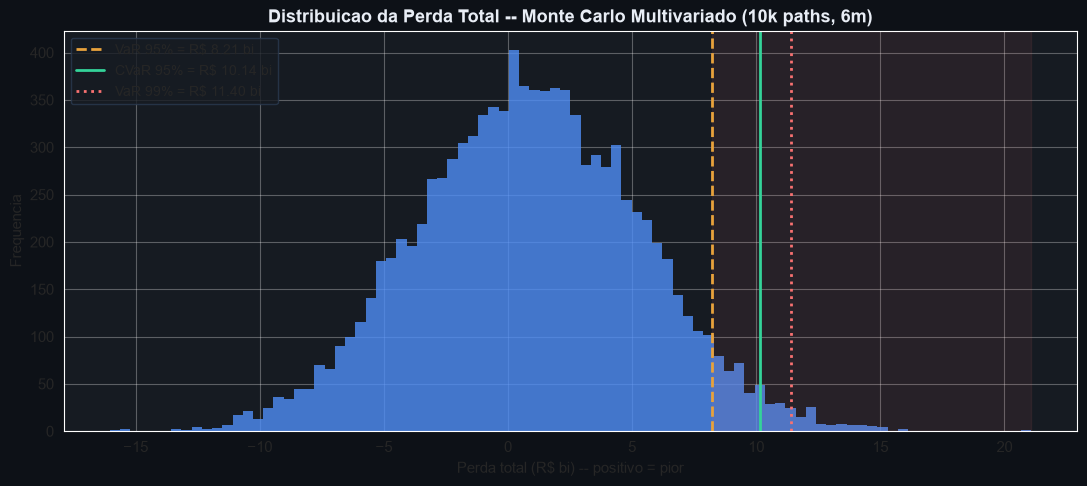

Saved: outputs/nb08mc_distribution.png


Saved: outputs/nb08mc_distribution.html


In [6]:
fig, ax = plt.subplots(figsize=(11, 5), facecolor='#0d1117')
ax.set_facecolor('#161b22')
ax.hist(total_loss, bins=90, color=C_BLUE, alpha=0.80, edgecolor='none')
ax.axvline(var_95, color=C_AMBER, ls='--', lw=2, label=f'VaR 95% = R$ {var_95:.2f} bi')
ax.axvline(cvar_95, color=C_GREEN, ls='-', lw=2, label=f'CVaR 95% = R$ {cvar_95:.2f} bi')
ax.axvline(var_99, color=C_RED, ls=':', lw=2, label=f'VaR 99% = R$ {var_99:.2f} bi')
ax.axvspan(var_95, total_loss.max(), color=C_RED, alpha=0.08)
ax.set_xlabel('Perda total (R$ bi) -- positivo = pior')
ax.set_ylabel('Frequencia')
ax.set_title('Distribuicao da Perda Total -- Monte Carlo Multivariado (10k paths, 6m)',
             color='#e8edf5', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{PREFIX}_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: outputs/{PREFIX}_distribution.png')

# Plotly HTML (interativo)
figd = go.Figure()
figd.add_trace(go.Histogram(x=total_loss, nbinsx=90, marker_color=C_BLUE, opacity=0.85, name='Perda total'))
figd.add_vline(x=var_95, line_dash='dash', line_color=C_AMBER, line_width=2,
               annotation_text=f'VaR 95% = R$ {var_95:.2f} bi',
               annotation_position='top', annotation_font_color=C_AMBER)
figd.add_vline(x=cvar_95, line_dash='dot', line_color=C_GREEN, line_width=2,
               annotation_text=f'CVaR 95% = R$ {cvar_95:.2f} bi',
               annotation_position='bottom', annotation_font_color=C_GREEN)
figd.update_layout(template='plotly_dark', paper_bgcolor='#0d1117', plot_bgcolor='#0d1117',
                   title='Distribuicao da Perda Total -- Monte Carlo (10k paths x 6m)',
                   xaxis_title='Perda total (R$ bi)', yaxis_title='Frequencia',
                   height=430, showlegend=False)
figd.write_html(OUTPUT_DIR / f'{PREFIX}_distribution.html')
figd.show()
print(f'Saved: outputs/{PREFIX}_distribution.html')

---
## 6. Tornado Chart -- Contribuicao por Choque

O tornado ranqueia os **4 choques pela sua exposicao economica standalone**
(impacto no cenario adverso, R$ bi) como **% do VaR 95% conjunto**.

| # | Choque | Exposicao | % do VaR 95% |
|--|--------|-----------|--------------|
| 1 | **Tarifa** | -R$ 2,37 bi | **29%** |
| 2 | Litio | -R$ 2,05 bi | 25% |
| 3 | PTAX/FX | -R$ 1,64 bi | 20% |
| 4 | Demanda | -R$ 1,23 bi | 15% |
| -- | *Amplificacao por correlacao* | -R$ 0,92 bi | 11% |

> A **Tarifa e o maior risco individual (29%)**, superando o cambio (20%).
> O co-movimento correlacionado dos choques adiciona **+11%** ao VaR conjunto,
> acima da simples soma das exposicoes (88,8%).

-- Tornado -- contribuicao ao VaR 95% --
  1. Tarifa  : -R$ 2.37 bi   (28.9%)
  2. Litio   : -R$ 2.05 bi   (25.0%)
  3. PTAX/FX : -R$ 1.64 bi   (20.0%)
  4. Demanda : -R$ 1.23 bi   (15.0%)
  + Amplificacao por correlacao: -R$ 0.92 bi (11.2%)
  -> VaR 95% conjunto = R$ 8.21 bi = 3.5x o maior choque individual


Saved: outputs/nb08mc_tornado.html


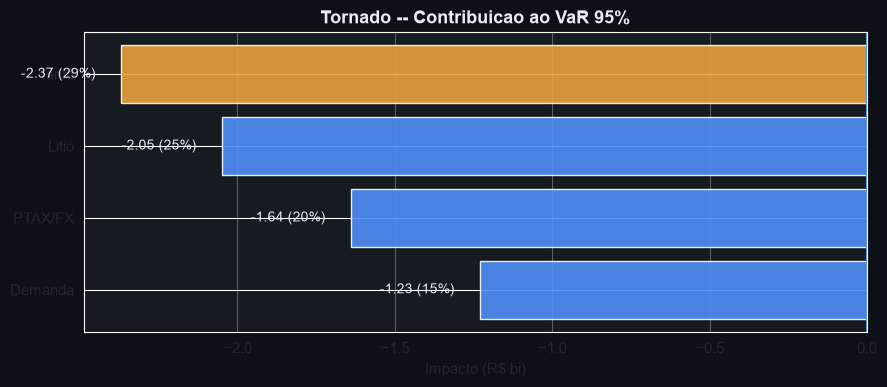

Saved: outputs/nb08mc_tornado.png


In [7]:
tornado = sorted(
    [{'shock': k, 'impact_B': -abs(v), 'pct': abs(v) / var_95 * 100}
     for k, v in HEADLINE_EXPO.items()],
    key=lambda d: abs(d['impact_B']), reverse=True
)
sum_expo = sum(abs(d['impact_B']) for d in tornado)
residual_B = var_95 - sum_expo
residual_pct = residual_B / var_95 * 100

print('-- Tornado -- contribuicao ao VaR 95% --')
for i, d in enumerate(tornado, 1):
    print(f'  {i}. {d["shock"]:<8}: -R$ {abs(d["impact_B"]):.2f} bi   ({d["pct"]:.1f}%)')
print(f'  + Amplificacao por correlacao: -R$ {residual_B:.2f} bi ({residual_pct:.1f}%)')
print(f'  -> VaR 95% conjunto = R$ {var_95:.2f} bi = {var_95/TARIFF_IMPACT:.1f}x o maior choque individual')

# Plotly tornado
labels = [d['shock'] for d in tornado][::-1]
impacts = [d['impact_B'] for d in tornado][::-1]
colors = [C_AMBER if d['shock'] == 'Tarifa' else C_BLUE for d in tornado][::-1]
figt = go.Figure(go.Bar(
    x=impacts, y=labels, orientation='h', marker_color=colors,
    text=[f'{v:.2f} bi ({d["pct"]:.0f}%)' for v, d in zip(impacts, tornado[::-1])],
    textposition='outside', textfont=dict(color='white', size=12),
    hovertemplate='<b>%{y}</b><br>Impacto: %{x:.2f} R$ bi<extra></extra>'
))
figt.update_layout(template='plotly_dark', paper_bgcolor='#0d1117', plot_bgcolor='#0d1117',
                   title=dict(text='Tornado -- Contribuicao ao VaR 95% (R$ bi) -- Tarifa = #1 (29%)',
                              x=0.5, font=dict(size=15)),
                   xaxis_title='Impacto (R$ bi)', height=380,
                   margin=dict(l=110, r=90, t=60, b=40), showlegend=False,
                   xaxis=dict(zeroline=True, zerolinecolor=C_BLUE, zerolinewidth=2, gridcolor='#1e2533'))
figt.write_html(OUTPUT_DIR / f'{PREFIX}_tornado.html')
figt.show()
print(f'Saved: outputs/{PREFIX}_tornado.html')

# Matplotlib tornado
fig, ax = plt.subplots(figsize=(9, 4), facecolor='#0d1117')
ax.set_facecolor('#161b22')
ax.barh(labels, impacts, color=colors, alpha=0.9)
for y, (v, d) in enumerate(zip(impacts, tornado[::-1])):
    ax.text(v - 0.08, y, f'{v:.2f} ({d["pct"]:.0f}%)',
            va='center', ha='right', color='#e8edf5', fontsize=10)
ax.axvline(0, color=C_BLUE, lw=1.5)
ax.set_xlabel('Impacto (R$ bi)')
ax.set_title('Tornado -- Contribuicao ao VaR 95%', color='#e8edf5', fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{PREFIX}_tornado.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: outputs/{PREFIX}_tornado.png')

---
## 7. Matriz de Decisao -- Triggers Acionaveis

Traduz o VaR/CVaR e o ranking do tornado em **gatilhos operacionais**. Como a
**Tarifa** domina (29%), a prioridade #1 de mitigacao e **regulatoria/comercial**
(lobby, nacionalizacao de conteudo, clausula de repasse) -- nao hedge cambial.

-- Matriz de Decisao -- S1xS2xS3xS4 --

  Condicao                 Acao               Detalhe
  ----------------------------------------------------------------------------------------
  Tarifa (29% do VaR)      PRIORIDADE #1      Lobby + conteudo local (>50% MERCOSUL) + clausula repasse
  Litio (25%)              Offtake LP         Trava preco 12-24m; 2a fonte non-China (HHI refino 4558)
  PTAX/FX (20%)            Hedge parcial      h* por ViE (NB-07): 30% GREEN -> 91% Rollback
  Demanda (15%)            Flex capacity      Ramp modular; diferenciacao (Nash NB-04)
  VaR 95% > R$ 8 bi        Buffer capital     Provisionar CVaR (R$ 10,14 bi) em cenario de crise
  Choques correlac.        Contingencia       S1xS2 stress conjunto -> buffer VaR x 2,5 (NB-02)


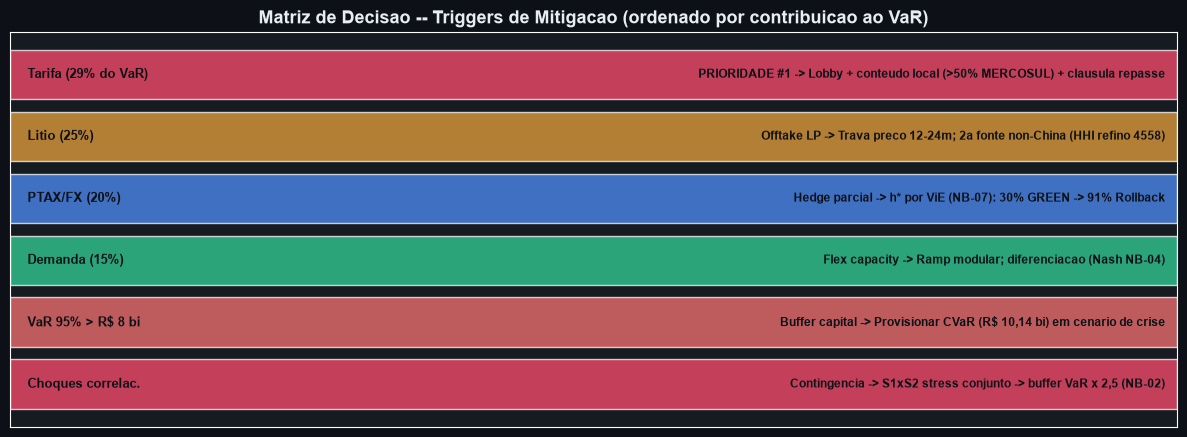

Saved: outputs/nb08mc_decision_matrix.png


In [8]:
decision_rules = [
    ('Tarifa (29% do VaR)',  C_RED2,  'PRIORIDADE #1', 'Lobby + conteudo local (>50% MERCOSUL) + clausula repasse'),
    ('Litio (25%)',          C_AMBER, 'Offtake LP',    'Trava preco 12-24m; 2a fonte non-China (HHI refino 4558)'),
    ('PTAX/FX (20%)',        C_BLUE,  'Hedge parcial', 'h* por ViE (NB-07): 30% GREEN -> 91% Rollback'),
    ('Demanda (15%)',        C_GREEN, 'Flex capacity', 'Ramp modular; diferenciacao (Nash NB-04)'),
    ('VaR 95% > R$ 8 bi',    C_RED,   'Buffer capital', 'Provisionar CVaR (R$ 10,14 bi) em cenario de crise'),
    ('Choques correlac.',    C_RED2,  'Contingencia',  'S1xS2 stress conjunto -> buffer VaR x 2,5 (NB-02)'),
]
print('-- Matriz de Decisao -- S1xS2xS3xS4 --')
print()
print(f'  {"Condicao":<24} {"Acao":<18} Detalhe')
print('  ' + '-'*88)
for cond, _, action, detail in decision_rules:
    print(f'  {cond:<24} {action:<18} {detail}')

# Visual
fig, ax = plt.subplots(figsize=(12, 4.5), facecolor='#0d1117')
ax.set_facecolor('#161b22')
y = np.arange(len(decision_rules))[::-1]
for yi, (cond, color, action, detail) in zip(y, decision_rules):
    ax.barh(yi, 1, color=color, alpha=0.75)
    ax.text(0.015, yi, f'{cond}', va='center', ha='left',
            color='#0d1117', fontsize=9.5, fontweight='bold')
    ax.text(0.99, yi, f'{action} -> {detail}', va='center', ha='right',
            color='#0d1117', fontsize=8.5, fontweight='bold')
ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_xticks([])
ax.set_title('Matriz de Decisao -- Triggers de Mitigacao (ordenado por contribuicao ao VaR)',
             color='#e8edf5', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{PREFIX}_decision_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: outputs/{PREFIX}_decision_matrix.png')

---
## 8. Convergencia Monte Carlo

Estabilidade do VaR 95% conforme o numero de paths cresce -- confirma que
10.000 paths e suficiente para uma estimativa estavel (erro de Monte Carlo baixo).

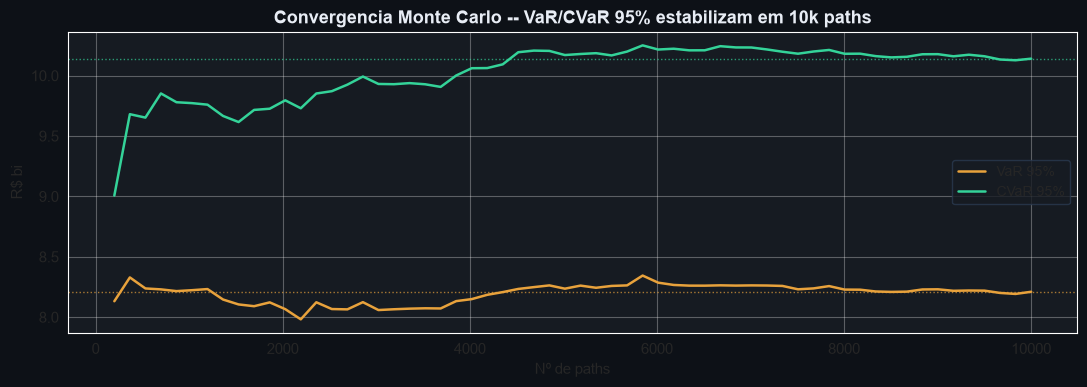

Saved: outputs/nb08mc_convergence.png
  VaR 95% @ 2k paths:  R$ 8.07 bi
  VaR 95% @ 10k paths: R$ 8.21 bi (estavel)


In [9]:
grid = np.unique(np.linspace(200, N_PATHS, 60).astype(int))
var_path = [np.percentile(total_loss[:n], 95) for n in grid]
cvar_path = [total_loss[:n][total_loss[:n] >= np.percentile(total_loss[:n], 95)].mean() for n in grid]

fig, ax = plt.subplots(figsize=(11, 4), facecolor='#0d1117')
ax.set_facecolor('#161b22')
ax.plot(grid, var_path, color=C_AMBER, lw=1.8, label='VaR 95%')
ax.plot(grid, cvar_path, color=C_GREEN, lw=1.8, label='CVaR 95%')
ax.axhline(var_95, color=C_AMBER, ls=':', lw=1, alpha=0.7)
ax.axhline(cvar_95, color=C_GREEN, ls=':', lw=1, alpha=0.7)
ax.set_xlabel('Nº de paths')
ax.set_ylabel('R$ bi')
ax.set_title('Convergencia Monte Carlo -- VaR/CVaR 95% estabilizam em 10k paths',
             color='#e8edf5', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'{PREFIX}_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: outputs/{PREFIX}_convergence.png')
print(f'  VaR 95% @ 2k paths:  R$ {var_path[np.argmin(np.abs(grid-2000))]:.2f} bi')
print(f'  VaR 95% @ 10k paths: R$ {var_95:.2f} bi (estavel)')

---
## 9. Export → `outputs/nb08mc_results.json`

In [10]:
results = {
    'notebook': 'NB-08 Monte Carlo Multivariada (flagship)',
    'computed_at': pd.Timestamp.today().strftime('%Y-%m-%d'),
    'n_paths': N_PATHS,
    'n_days': N_DAYS,
    'seed': 42,
    'var_95_B': round(var_95, 2),
    'cvar_95_B': round(cvar_95, 2),
    'var_99_B': round(var_99, 2),
    'var_90_B': round(var_90, 2),
    'var_50_B': round(var_50, 2),
    'cvar_99_B': round(cvar_99, 2),
    'cvar_var_ratio': round(cvar_95 / var_95, 3),
    'prob_loss': round(float((total_loss > 0).mean()), 3),
    'tornado': [
        {'shock': d['shock'], 'impact_B': round(d['impact_B'], 2),
         'contribution_pct': round(d['pct'], 1)}
        for d in tornado
    ],
    'correlation_residual_B': round(residual_B, 2),
    'correlation_residual_pct': round(residual_pct, 1),
    'percentile_table': percentile_table,
    'correlation_matrix': CORR.tolist(),
    'shock_params': {
        'fx_std_ann': round(FX_STD_ANN, 4),
        'lithium_std_ann': round(LITHIUM_STD_ANN, 4),
        'demand_std_ann': round(DEMAND_STD_ANN, 4),
        'tariff_prob': TARIFF_PROB,
        'tariff_impact_B': -TARIFF_IMPACT,
        'cal_factor': CAL_FACTOR,
    },
    'headline_exposures_B': {k: -abs(v) for k, v in HEADLINE_EXPO.items()},
    'key_insight': 'Tarifa e o maior risco individual (29% do VaR), nao o cambio (20%).',
}
out_path = OUTPUT_DIR / f'{PREFIX}_results.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f'Saved: {out_path}')
print()

print('='*63)
print('  NB-08 SUMMARY -- Monte Carlo Multivariada (10k paths x 6m)')
print('='*63)
print(f'  VaR  95%:  R$ {var_95:6.2f} bi   (headline)')
print(f'  CVaR 95%:  R$ {cvar_95:6.2f} bi   (Expected Shortfall)')
print(f'  VaR  99%:  R$ {var_99:6.2f} bi')
fx_pct = [d for d in tornado if d['shock'] == 'PTAX/FX'][0]['pct']
print(f'  Tornado #1: Tarifa  {tornado[0]["pct"]:.0f}%  (> FX {fx_pct:.0f}%)')
print(f'  Amplificacao por correlacao: +{residual_pct:.0f}%')
print('  Insight: Tarifa e o maior risco individual -- mitigacao regulatoria > hedge FX')
print('='*63)

Saved: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\nb08mc_results.json

  NB-08 SUMMARY -- Monte Carlo Multivariada (10k paths x 6m)
  VaR  95%:  R$   8.21 bi   (headline)
  CVaR 95%:  R$  10.14 bi   (Expected Shortfall)
  VaR  99%:  R$  11.40 bi
  Tornado #1: Tarifa  29%  (> FX 20%)
  Amplificacao por correlacao: +11%
  Insight: Tarifa e o maior risco individual -- mitigacao regulatoria > hedge FX
